# Lab Report 04 - Running Code

This notebook contains the full runnable practical for `Lab Report 04` with separate Python cells and explanatory comments.

In [1]:
# Import required libraries.
# cv2        -> filtering, padding, drawing, and image operations
# numpy      -> kernel creation, padding, and numeric processing
# matplotlib -> image display and result visualization
# pathlib    -> safe path handling for the input image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set default plot size.
plt.rcParams["figure.figsize"] = (10, 8)

In [2]:
# Search for Girl.jpg in likely working locations.
candidate_paths = [
    Path("Girl.jpg"),
    Path("../Girl.jpg"),
    Path(r"C:/Users/kavin/OneDrive/Documents/Projects/Digital Image Processing and Computer Vision/Girl.jpg"),
]

image_path = next((path for path in candidate_paths if path.exists()), None)

if image_path is None:
    raise FileNotFoundError(
        "Could not find 'Girl.jpg'. Keep it in the project root or current working directory."
    )

# Read the image using OpenCV.
# OpenCV loads color images in BGR format.
img = cv2.imread(str(image_path))

if img is None:
    raise ValueError(f"OpenCV could not read the image: {image_path}")

# Convert the image for display and grayscale processing.
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Image loaded successfully!")
print(f"Image path: {image_path.resolve()}")
print(f"Original size: {img.shape[1]} x {img.shape[0]}")
print(f"Grayscale image shape: {gray.shape}")

Image loaded successfully!
Image path: C:\Users\kavin\OneDrive\Documents\Projects\Digital Image Processing and Computer Vision\Girl.jpg
Original size: 512 x 512
Grayscale image shape: (512, 512)


In [3]:
# Define a manual 3x3 averaging filter.
# The image is padded with edge values so border pixels can also be filtered.
def average_filter_manual(image):
    h, w = image.shape
    output = np.zeros_like(image)
    padded = np.pad(image, pad_width=1, mode="edge")

    for y in range(h):
        for x in range(w):
            neighborhood = padded[y:y+3, x:x+3]
            output[y, x] = np.mean(neighborhood)

    return output.astype(np.uint8)

# Apply the manual method.
smoothed_manual = average_filter_manual(gray)
print("Manual 3x3 averaging filter applied successfully!")

Manual 3x3 averaging filter applied successfully!


In [4]:
# Create the 3x3 averaging kernel.
# Each value is 1/9 so the sum of the kernel is 1.
kernel_3x3 = np.ones((3, 3), np.float32) / 9.0

# Apply convolution using OpenCV's general filter2D function.
smoothed_filter2d = cv2.filter2D(gray, -1, kernel_3x3)

print("cv2.filter2D() with 3x3 averaging kernel applied!")
print("Kernel used:")
print(kernel_3x3)

cv2.filter2D() with 3x3 averaging kernel applied!
Kernel used:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


In [5]:
# Apply the optimized mean filter using cv2.blur().
smoothed_fast = cv2.blur(gray, (3, 3))
print("Fast smoothing using cv2.blur() applied successfully!")

Fast smoothing using cv2.blur() applied successfully!


In [6]:
# Add random noise to the grayscale image.
# int16 is used temporarily so addition does not overflow.
np.random.seed(42)
noise = np.random.randint(-30, 31, gray.shape, dtype=np.int16)
noisy = np.clip(gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Smooth the noisy image using the averaging filter.
noisy_smoothed = cv2.blur(noisy, (3, 3))

print("Noise added and noisy image smoothed successfully!")

Noise added and noisy image smoothed successfully!


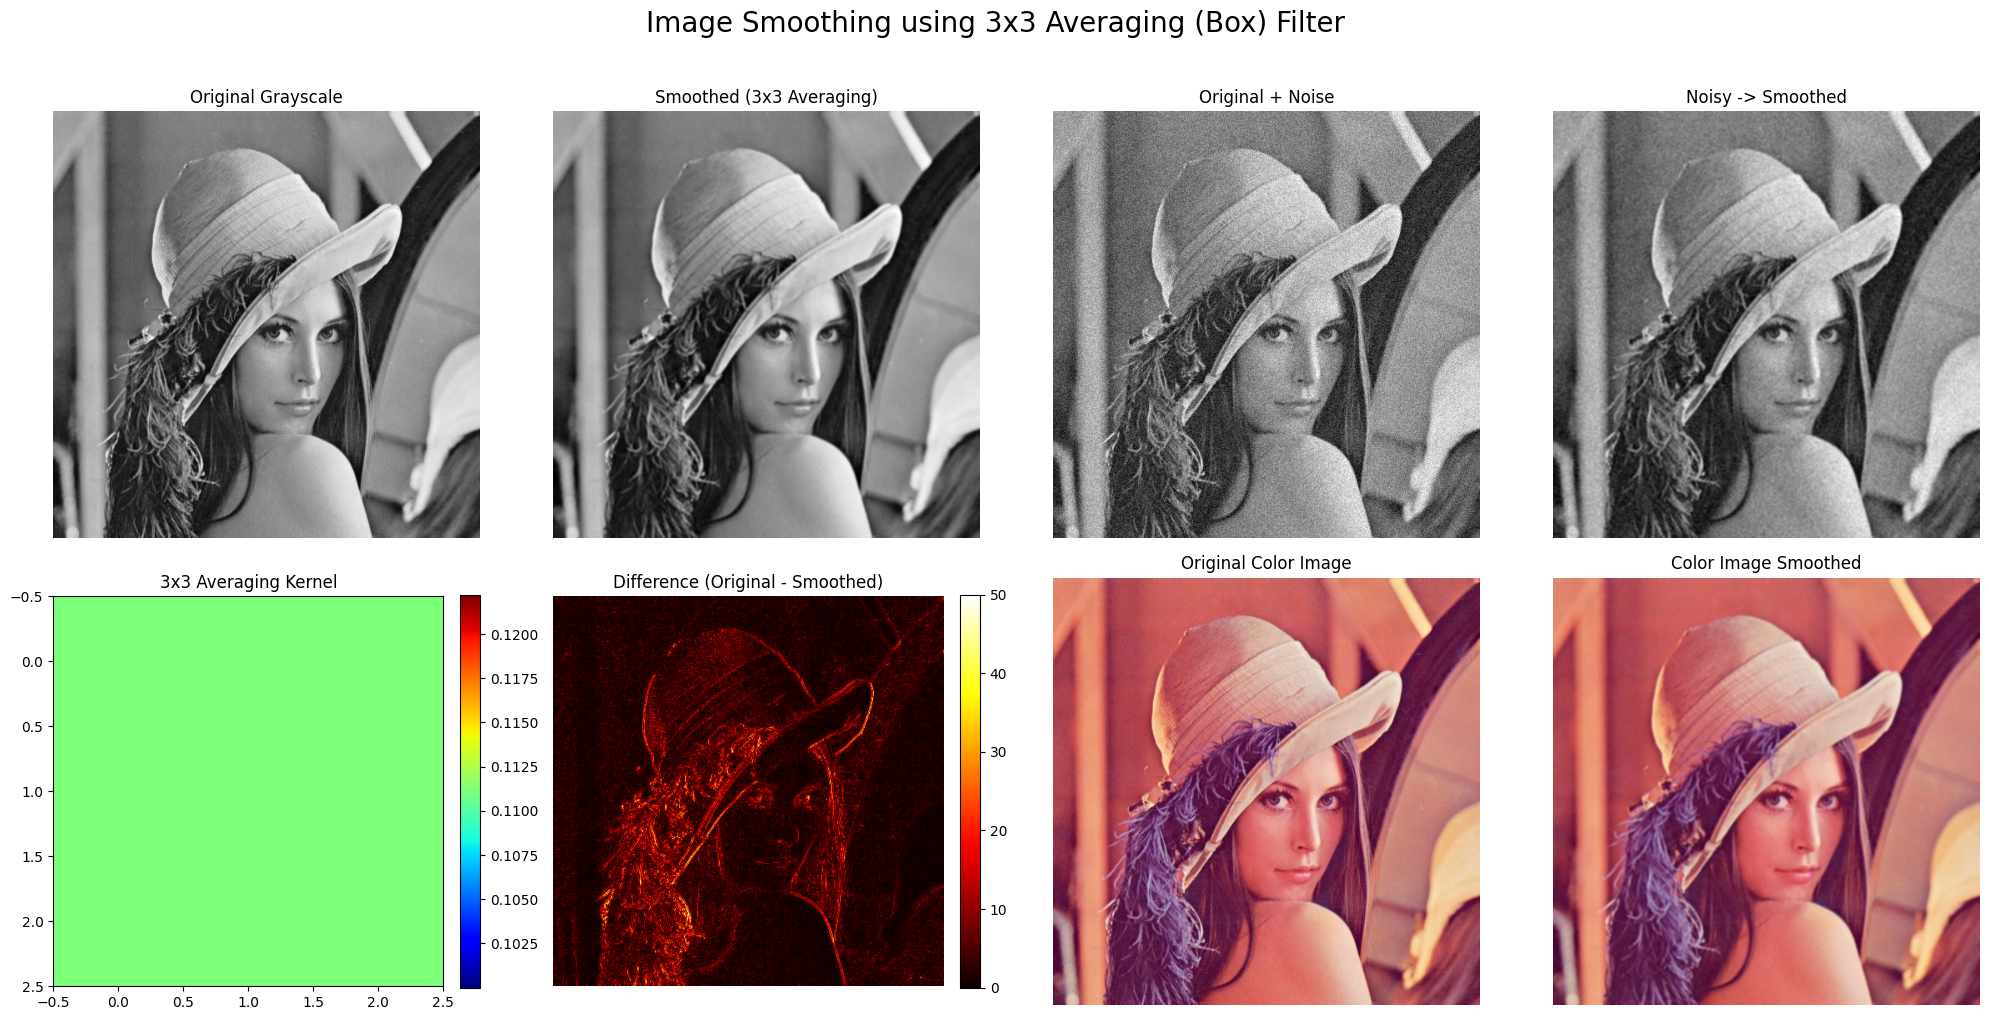

3x3 averaging filter applied successfully!
Output shapes:
Manual method: (512, 512)
cv2.filter2D(): (512, 512)
cv2.blur(): (512, 512)


In [7]:
# Display the main smoothing results.
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

axes[0, 0].imshow(gray, cmap="gray")
axes[0, 0].set_title("Original Grayscale")
axes[0, 0].axis("off")

axes[0, 1].imshow(smoothed_fast, cmap="gray")
axes[0, 1].set_title("Smoothed (3x3 Averaging)")
axes[0, 1].axis("off")

axes[0, 2].imshow(noisy, cmap="gray")
axes[0, 2].set_title("Original + Noise")
axes[0, 2].axis("off")

axes[0, 3].imshow(noisy_smoothed, cmap="gray")
axes[0, 3].set_title("Noisy -> Smoothed")
axes[0, 3].axis("off")

kernel_display = axes[1, 0].imshow(kernel_3x3, cmap="jet", interpolation="nearest")
axes[1, 0].set_title("3x3 Averaging Kernel")
plt.colorbar(kernel_display, ax=axes[1, 0], fraction=0.046, pad=0.04)

diff = cv2.absdiff(gray, smoothed_fast)
diff_display = axes[1, 1].imshow(diff, cmap="hot", vmin=0, vmax=50)
axes[1, 1].set_title("Difference (Original - Smoothed)")
axes[1, 1].axis("off")
plt.colorbar(diff_display, ax=axes[1, 1], fraction=0.046, pad=0.04)

axes[1, 2].imshow(img_rgb)
axes[1, 2].set_title("Original Color Image")
axes[1, 2].axis("off")

smoothed_color = cv2.blur(img_rgb, (3, 3))
axes[1, 3].imshow(smoothed_color)
axes[1, 3].set_title("Color Image Smoothed")
axes[1, 3].axis("off")

plt.suptitle("Image Smoothing using 3x3 Averaging (Box) Filter", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

print("3x3 averaging filter applied successfully!")
print("Output shapes:")
print(f"Manual method: {smoothed_manual.shape}")
print(f"cv2.filter2D(): {smoothed_filter2d.shape}")
print(f"cv2.blur(): {smoothed_fast.shape}")

In [8]:
# Compare the outputs of the three smoothing methods.
diff_methods = cv2.absdiff(smoothed_manual, smoothed_filter2d)
diff_methods2 = cv2.absdiff(smoothed_filter2d, smoothed_fast)

print("Difference between manual method and cv2.filter2D():")
print(f"Max difference: {diff_methods.max()}")
print(f"Mean difference: {diff_methods.mean():.6f}")
print()
print("Difference between cv2.filter2D() and cv2.blur():")
print(f"Max difference: {diff_methods2.max()}")
print(f"Mean difference: {diff_methods2.mean():.6f}")

Difference between manual method and cv2.filter2D():
Max difference: 11
Mean difference: 0.445862

Difference between cv2.filter2D() and cv2.blur():
Max difference: 0
Mean difference: 0.000000


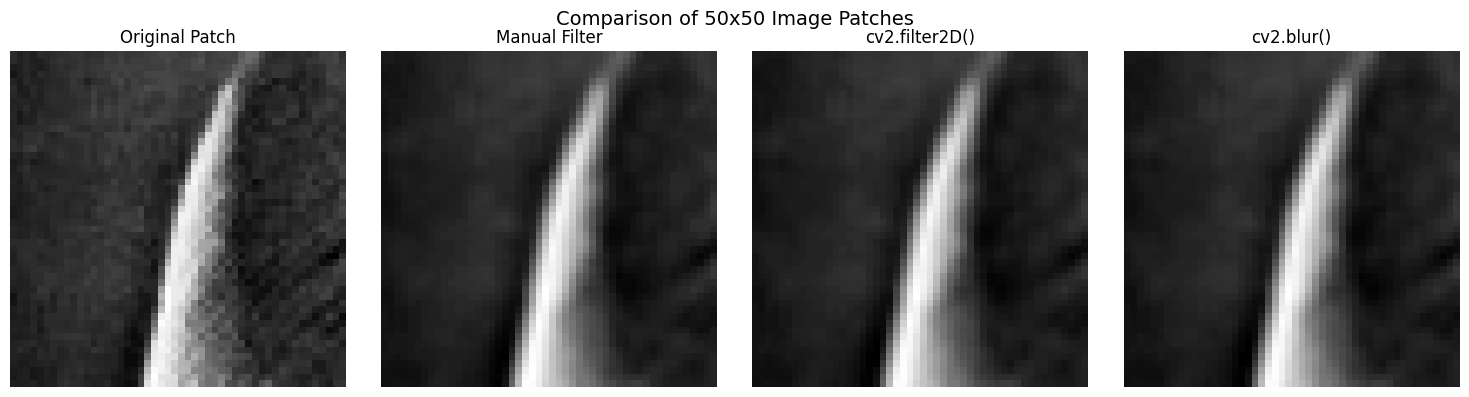

In [9]:
# Show a small patch from the image for closer comparison of the filtering methods.
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

patch_y, patch_x = 100, 100
patch_size = 50

patch_original = gray[patch_y:patch_y+patch_size, patch_x:patch_x+patch_size]
patch_manual = smoothed_manual[patch_y:patch_y+patch_size, patch_x:patch_x+patch_size]
patch_filter2d = smoothed_filter2d[patch_y:patch_y+patch_size, patch_x:patch_x+patch_size]
patch_blur = smoothed_fast[patch_y:patch_y+patch_size, patch_x:patch_x+patch_size]

axes[0].imshow(patch_original, cmap="gray")
axes[0].set_title("Original Patch")
axes[0].axis("off")

axes[1].imshow(patch_manual, cmap="gray")
axes[1].set_title("Manual Filter")
axes[1].axis("off")

axes[2].imshow(patch_filter2d, cmap="gray")
axes[2].set_title("cv2.filter2D()")
axes[2].axis("off")

axes[3].imshow(patch_blur, cmap="gray")
axes[3].set_title("cv2.blur()")
axes[3].axis("off")

plt.suptitle("Comparison of 50x50 Image Patches", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Create a checkerboard image for padding experiments.
def create_checkerboard(size=8, num_tiles=8):
    re = np.r_[num_tiles * [0, 1]]
    ro = np.r_[num_tiles * [1, 0]]
    board = np.vstack(num_tiles * (re, ro))
    board = cv2.resize(
        board.astype("uint8") * 255,
        (size * 20, size * 20),
        interpolation=cv2.INTER_NEAREST,
    )
    return board

# Create two simple synthetic grayscale test images.
checkerboard = create_checkerboard()
rectangle = np.ones((300, 300), dtype=np.uint8) * 255
rectangle[50:250, 80:220] = 0

print("Test images created successfully!")
print(f"Checkerboard shape: {checkerboard.shape}")
print(f"Rectangle shape: {rectangle.shape}")

Test images created successfully!
Checkerboard shape: (160, 160)
Rectangle shape: (300, 300)


In [11]:
# Choose one synthetic image for the padding experiment.
# You can change this to checkerboard if needed.
gray2 = rectangle.copy()

# Define the same 3x3 averaging kernel and padding size.
kernel = np.ones((3, 3), np.float32) / 9
pad = 1

print("Padding experiment image loaded successfully!")
print(f"Image shape: {gray2.shape}")
print("Kernel:")
print(kernel)

Padding experiment image loaded successfully!
Image shape: (300, 300)
Kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


In [12]:
# Define the padding methods to compare.
padding_modes = [
    ("BORDER_CONSTANT (Zero)", cv2.BORDER_CONSTANT, 0),
    ("BORDER_REPLICATE (Edge)", cv2.BORDER_REPLICATE, None),
    ("BORDER_REFLECT", cv2.BORDER_REFLECT, None),
    ("BORDER_REFLECT_101", cv2.BORDER_REFLECT_101, None),
    ("BORDER_WRAP", cv2.BORDER_WRAP, None),
    ("No Padding (Valid)", None, None),
]

print("Padding modes to compare:")
for i, (name, border_type, value) in enumerate(padding_modes, 1):
    print(f"{i}. {name}")

Padding modes to compare:
1. BORDER_CONSTANT (Zero)
2. BORDER_REPLICATE (Edge)
3. BORDER_REFLECT
4. BORDER_REFLECT_101
5. BORDER_WRAP
6. No Padding (Valid)


In [13]:
# Apply convolution using each padding mode and store the results.
results = []

for name, border_type, const_value in padding_modes:
    if border_type is None:
        full = cv2.filter2D(gray2, -1, kernel, borderType=cv2.BORDER_CONSTANT)
        cropped = full[pad:-pad, pad:-pad]
        results.append((name, cropped))
        print(f"{name}: output shape = {cropped.shape}")

    elif border_type == cv2.BORDER_CONSTANT:
        padded = cv2.copyMakeBorder(
            gray2, pad, pad, pad, pad, borderType=cv2.BORDER_CONSTANT, value=const_value
        )
        filtered_full = cv2.filter2D(padded, -1, kernel, borderType=cv2.BORDER_CONSTANT)
        filtered = filtered_full[pad:-pad, pad:-pad]
        results.append((name, filtered))
        print(f"{name}: output shape = {filtered.shape}")

    elif border_type == cv2.BORDER_WRAP:
        padded = cv2.copyMakeBorder(gray2, pad, pad, pad, pad, borderType=cv2.BORDER_WRAP)
        filtered_full = cv2.filter2D(padded, -1, kernel, borderType=cv2.BORDER_REPLICATE)
        filtered = filtered_full[pad:-pad, pad:-pad]
        results.append((name, filtered))
        print(f"{name}: output shape = {filtered.shape}")

    else:
        filtered = cv2.filter2D(gray2, -1, kernel, borderType=border_type)
        results.append((name, filtered))
        print(f"{name}: output shape = {filtered.shape}")

print(f"\nAll {len(results)} padding methods processed successfully!")

BORDER_CONSTANT (Zero): output shape = (300, 300)
BORDER_REPLICATE (Edge): output shape = (300, 300)
BORDER_REFLECT: output shape = (300, 300)
BORDER_REFLECT_101: output shape = (300, 300)
BORDER_WRAP: output shape = (300, 300)
No Padding (Valid): output shape = (298, 298)

All 6 padding methods processed successfully!


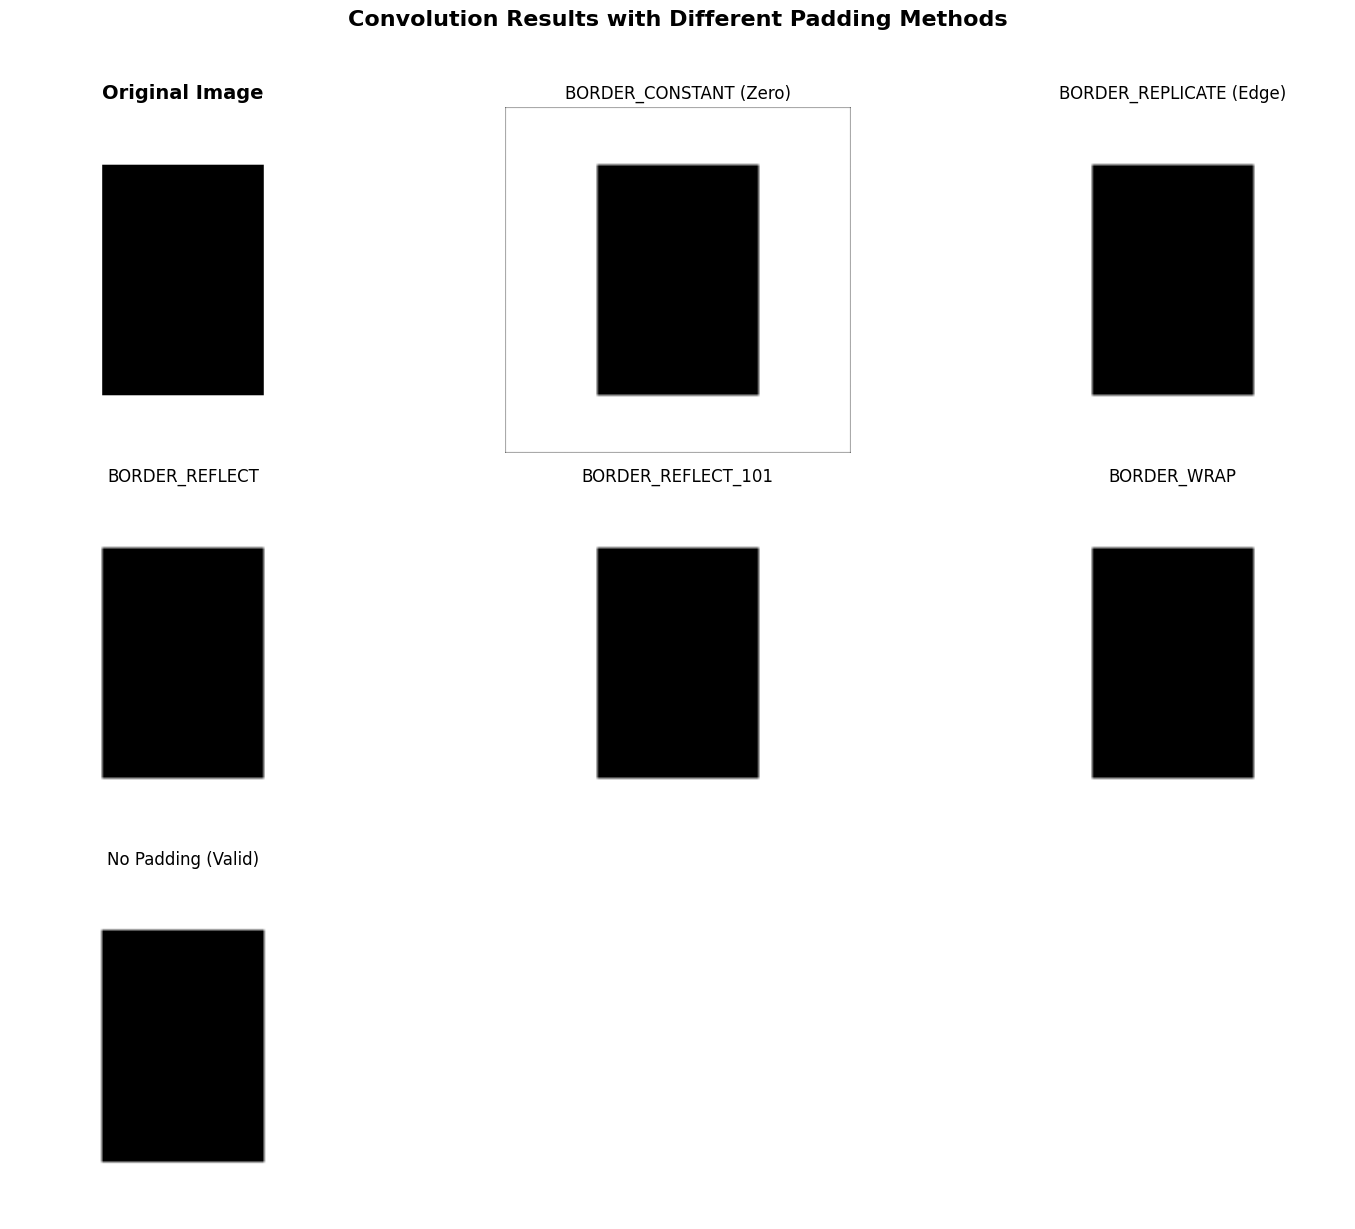

In [14]:
# Visualize the original test image and all padding results.
plt.figure(figsize=(15, 12))

plt.subplot(3, 3, 1)
plt.imshow(gray2, cmap="gray")
plt.title("Original Image", fontsize=14, fontweight="bold")
plt.xlabel(f"{gray2.shape[1]} x {gray2.shape[0]}")
plt.axis("off")

for i, (title, img_out) in enumerate(results, start=2):
    plt.subplot(3, 3, i)
    plt.imshow(img_out, cmap="gray")
    plt.title(title, fontsize=12)
    plt.xlabel(f"{img_out.shape[1]} x {img_out.shape[0]}")
    plt.axis("off")

plt.suptitle("Convolution Results with Different Padding Methods", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

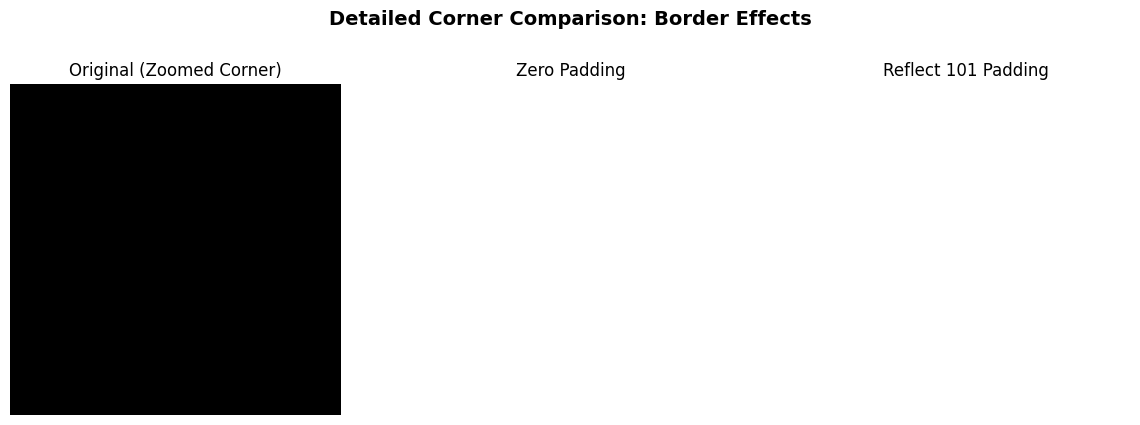

In [15]:
# Compare border behavior more closely using a zoomed corner region.
zoom_y, zoom_x, size = 20, 20, 40

zero_padded = cv2.copyMakeBorder(gray2, pad, pad, pad, pad, borderType=cv2.BORDER_CONSTANT, value=0)
zero_full = cv2.filter2D(zero_padded, -1, kernel, borderType=cv2.BORDER_CONSTANT)
zero_result = zero_full[pad:-pad, pad:-pad]

reflect_result = cv2.filter2D(gray2, -1, kernel, borderType=cv2.BORDER_REFLECT_101)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(gray2[zoom_y:zoom_y+size, zoom_x:zoom_x+size], cmap="gray")
axes[0].set_title("Original (Zoomed Corner)")
axes[0].axis("off")

axes[1].imshow(zero_result[zoom_y:zoom_y+size, zoom_x:zoom_x+size], cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Zero Padding")
axes[1].axis("off")

axes[2].imshow(reflect_result[zoom_y:zoom_y+size, zoom_x:zoom_x+size], cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Reflect 101 Padding")
axes[2].axis("off")

plt.suptitle("Detailed Corner Comparison: Border Effects", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [16]:
# Print a brief summary of the padding methods and their effects.
print("=" * 60)
print("PADDING METHODS SUMMARY")
print("=" * 60)
print("\n1. BORDER_CONSTANT (Zero Padding):")
print("   - Adds zeros around the image")
print("   - Can create dark borders in the filtered result")
print("\n2. BORDER_REPLICATE (Edge Padding):")
print("   - Repeats the border pixels")
print("   - Helps preserve edge intensity")
print("\n3. BORDER_REFLECT / BORDER_REFLECT_101:")
print("   - Reflects the image around its borders")
print("   - Reflect_101 excludes the edge pixel itself")
print("\n4. BORDER_WRAP:")
print("   - Wraps image values from opposite side")
print("   - Useful for periodic patterns")
print("\n5. No Padding (Valid Convolution):")
print("   - Output becomes smaller")
print("   - Border pixels are removed")
print("\n" + "=" * 60)
print("Key Insight:")
print("Padding mainly affects border pixels, while inner pixels")
print("usually remain very similar across different methods.")
print("=" * 60)

PADDING METHODS SUMMARY

1. BORDER_CONSTANT (Zero Padding):
   - Adds zeros around the image
   - Can create dark borders in the filtered result

2. BORDER_REPLICATE (Edge Padding):
   - Repeats the border pixels
   - Helps preserve edge intensity

3. BORDER_REFLECT / BORDER_REFLECT_101:
   - Reflects the image around its borders
   - Reflect_101 excludes the edge pixel itself

4. BORDER_WRAP:
   - Wraps image values from opposite side
   - Useful for periodic patterns

5. No Padding (Valid Convolution):
   - Output becomes smaller
   - Border pixels are removed

Key Insight:
Padding mainly affects border pixels, while inner pixels
usually remain very similar across different methods.


Synthetic test image created successfully!
Shape: (200, 200)
Data type: uint8
Min pixel value: 0
Max pixel value: 255


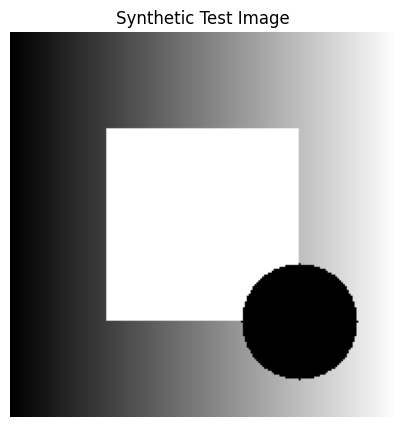

In [17]:
# Create a second synthetic test image with a gradient, rectangle, and circle.
def create_test_image(size=200):
    img = np.zeros((size, size), dtype=np.uint8)

    for i in range(size):
        img[:, i] = i * 255 // size

    img[50:150, 50:150] = 255
    cv2.circle(img, (150, 150), 30, 0, -1)
    return img

test_img = create_test_image(200)

print("Synthetic test image created successfully!")
print(f"Shape: {test_img.shape}")
print(f"Data type: {test_img.dtype}")
print(f"Min pixel value: {test_img.min()}")
print(f"Max pixel value: {test_img.max()}")

plt.figure(figsize=(5, 5))
plt.imshow(test_img, cmap="gray")
plt.title("Synthetic Test Image")
plt.axis("off")
plt.show()